## 用 GARCH 预测股票未来波动率

- **思路**：用历史日收益率拟合 GARCH(1,1)，得到条件波动率序列，再向前预测未来若干日的波动率。
- **依赖**：`arch`、`pandas`、`numpy`；数据源为 `yfinance`（可改为 OpenBB）。
- **输出**：日度波动率（%）、年化波动率（%），以及历史条件波动率与未来预测的图示。

In [7]:
# 必须在 import 任何会加载 protobuf 的库（含 futu）之前设置，否则 futu 会报 Descriptors cannot be created directly
import os
os.environ["PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION"] = "python"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from arch import arch_model
import logging
import warnings
from futu import *

# 隐藏 matplotlib 字体相关警告（不使用中文时无需 CJK 字体）
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib")

# 模块导入（./module/）
from module.config import SYMBOL, START, END, GARCH_HORIZON_DAYS, IV_HORIZON_DAYS, FUTU_HOST, FUTU_PORT
from module.iv_module import get_futu_iv
from module.data_module import get_stock_prices, returns_from_prices
from module.garch_module import get_volatility_metrics
from module.viz_module import plot_hv_garch

In [ ]:
# 【重要】windows .wslconfig 需要配置
# [wsl2] networkingMode=mirrored
# [experimental] localhostForwarding=true
# openD 监听ip 0.0.0.0
#
# 隐含波动率（VIX 风格 / 方差空间插值）→ iv_module.py

# 数据与 GARCH：见 data_module.py, garch_module.py

# 可视化：见 viz_module.py



标的 TSM 波动率对比（HV / IV / GARCH）


/home/lhsok/miniconda3/envs/trading/lib/python3.10/site-packages/arch/univariate/base.py:2056: FutureWarning: Dtype inference on a pandas object (Series, Index, ExtensionArray) is deprecated. The Index constructor will keep the original dtype in the future. Call `infer_objects` on the result to get the old behavior.
  self._index = pd.Index(index)


,HV annual %,IV annual %,GARCH T+1 annual %,GARCH T+22 annual %,price,expected move,expected range
TSM,36.62,49.08,32.23,32.11,374.58,35.54,339.04 ~ 410.12


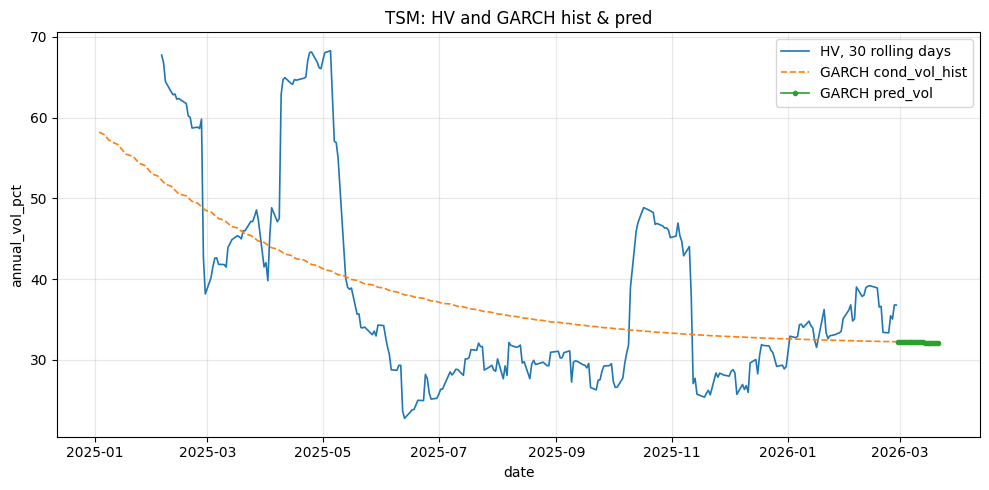

In [8]:
# 配置：标的与样本区间；一次调用完成价格(缓存)、HV、IV(缓存)、GARCH
SYMBOL = "TSM"
START = "2025-01-01"
END = None
HORIZON_DAYS = 25

result = get_volatility_metrics(SYMBOL, START, END, garch_horizon_days=GARCH_HORIZON_DAYS, iv_horizon_days=IV_HORIZON_DAYS)
prices = result["prices"]
returns = result["returns"]
fit = result["fit"]
forecast = result["forecast"]
annual_vol_pct = result["annual_vol_pct"]
cond_vol_pct = result["cond_vol_pct"]
vol_table = result["vol_table"]
cond_vol_hist = result["cond_vol_hist"]
garch_vol_series = result["garch_vol_series"]
hv_series = result["hv_series"]

print(f"标的 " + SYMBOL + " 波动率对比（HV / IV / GARCH）")
display(result["vol_table"])
plot_hv_garch(result, SYMBOL)

In [6]:
# GARCH 拟合结果（已在 get_volatility_metrics 内完成）
print(fit.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                  Close   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -665.993
Distribution:                  Normal   AIC:                           1339.99
Method:            Maximum Likelihood   BIC:                           1354.64
                                        No. Observations:                  288
Date:                Sun, Mar 01 2026   Df Residuals:                      287
Time:                        15:55:12   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.2701      0.137      1.969  4.895e-02 [1.249e-0

### 比较与验证模型
- 评估预测准确性：将GARCH预测值与未来的已实现波动率（未来HV）进行比较，检验模型的预测能力。也可以对比IV与未来实现波动率，判断期权定价是否合理。

- 识别系统性偏差：如果IV长期高于GARCH预测或未来实现波动率，可能说明市场存在恐慌溢价；反之则可能低估风险。

- 观察波动率期限结构：比较不同期限的HV、IV和GARCH预测，可以了解短期与长期波动预期的差异，判断市场对近期事件的反应。

### 波动率套利（Volatility Arbitrage）：

- 当IV显著高于GARCH预测的未来波动率 时，意味着期权可能被高估，可考虑卖出期权（做空波动率），同时用标的资产对冲Delta风险，等待IV回归。

- 当IV显著低于GARCH预测 时，期权可能被低估，可考虑买入期权（做多波动率）。
注意：需要设置合理的阈值和仓位管理，因为GARCH预测也可能有误差。

### 方向性交易辅助：

- 如果GARCH预测波动率即将上升，而当前市场情绪平稳（IV较低），可提前布局波动率多头（如跨式期权）。

- 如果HV已处于历史高位，且GARCH预测将回落，同时IV仍高企，可考虑做空波动率。

2026-03-01 16:40:48,414 | 11753 | 123246168724992 | [open_context_base.py:409] _init_connect_sync: New connect ready: conn=7433793352394165598(2) context=<futu.quote.open_quote_context.OpenQuoteContext object at 0x701712f6b1c0>
标的 AAPL 波动率对比（HV / IV / GARCH）


/home/lhsok/miniconda3/envs/trading/lib/python3.10/site-packages/arch/univariate/base.py:2056: FutureWarning: Dtype inference on a pandas object (Series, Index, ExtensionArray) is deprecated. The Index constructor will keep the original dtype in the future. Call `infer_objects` on the result to get the old behavior.
  self._index = pd.Index(index)


,HV annual %,IV annual %,GARCH T+1 annual %,GARCH T+30 annual %,price,expected move,expected range
AAPL,30.79,31.97,32.26,32.08,264.18,23.76,240.42 ~ 287.94


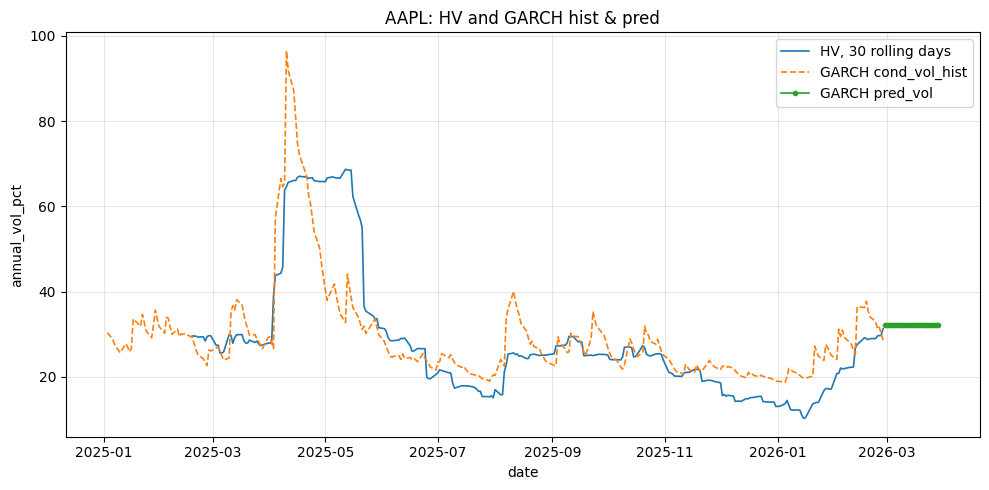

标的 MSFT 波动率对比（HV / IV / GARCH）


/home/lhsok/miniconda3/envs/trading/lib/python3.10/site-packages/arch/univariate/base.py:2056: FutureWarning: Dtype inference on a pandas object (Series, Index, ExtensionArray) is deprecated. The Index constructor will keep the original dtype in the future. Call `infer_objects` on the result to get the old behavior.
  self._index = pd.Index(index)


,HV annual %,IV annual %,GARCH T+1 annual %,GARCH T+30 annual %,price,expected move,expected range
MSFT,42.25,31.83,33.18,36.88,392.74,40.61,352.13 ~ 433.35


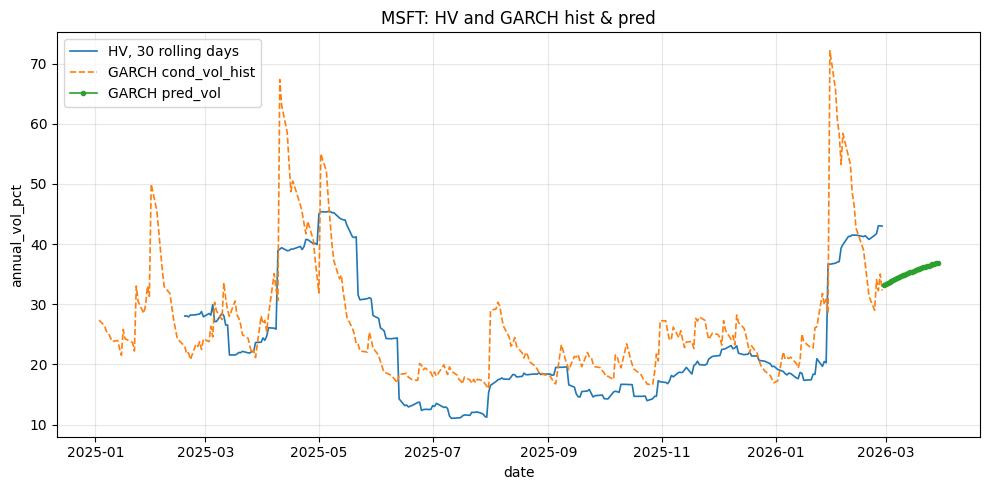

标的 SPY 波动率对比（HV / IV / GARCH）


/home/lhsok/miniconda3/envs/trading/lib/python3.10/site-packages/arch/univariate/base.py:2056: FutureWarning: Dtype inference on a pandas object (Series, Index, ExtensionArray) is deprecated. The Index constructor will keep the original dtype in the future. Call `infer_objects` on the result to get the old behavior.
  self._index = pd.Index(index)


,HV annual %,IV annual %,GARCH T+1 annual %,GARCH T+30 annual %,price,expected move,expected range
SPY,12.72,—,12.92,15.94,685.99,30.65,655.34 ~ 716.64


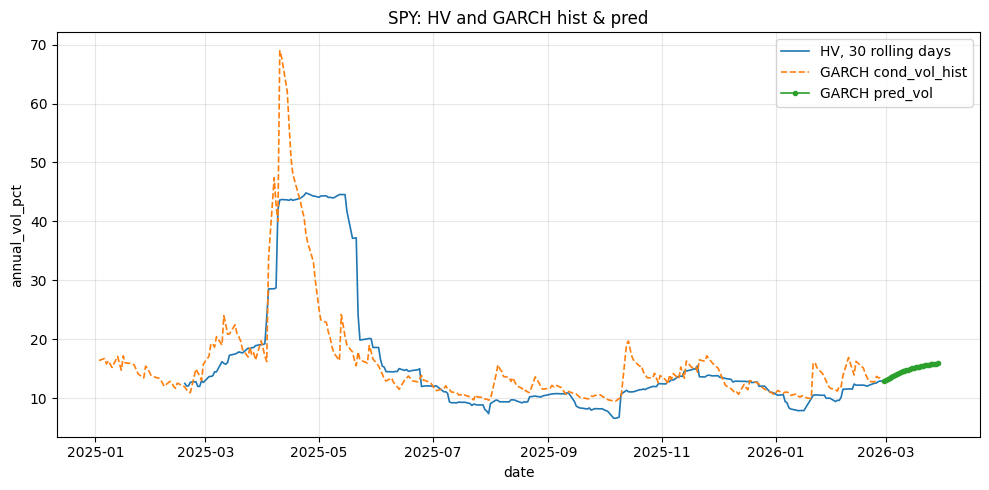

/home/lhsok/playground/trading/module/iv_module.py:281: RuntimeWarning: invalid value encountered in sqrt
  iv_30d = float(np.sqrt(v_horizon * 365 / horizon) * 100)


标的 QQQ 波动率对比（HV / IV / GARCH）


/home/lhsok/miniconda3/envs/trading/lib/python3.10/site-packages/arch/univariate/base.py:2056: FutureWarning: Dtype inference on a pandas object (Series, Index, ExtensionArray) is deprecated. The Index constructor will keep the original dtype in the future. Call `infer_objects` on the result to get the old behavior.
  self._index = pd.Index(index)


,HV annual %,IV annual %,GARCH T+1 annual %,GARCH T+30 annual %,price,expected move,expected range
QQQ,17.23,—,17.8,21.23,607.29,36.13,571.16 ~ 643.42


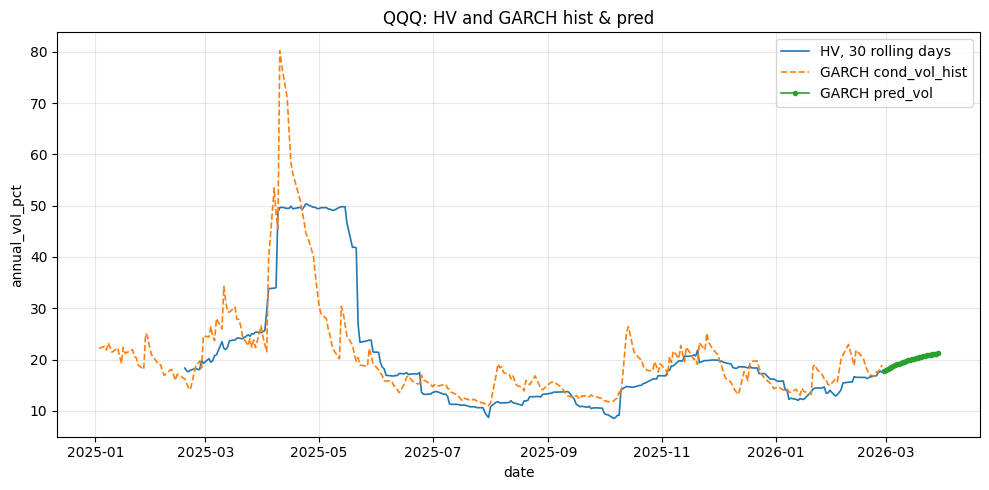

标的 DIA 波动率对比（HV / IV / GARCH）


/home/lhsok/miniconda3/envs/trading/lib/python3.10/site-packages/arch/univariate/base.py:2056: FutureWarning: Dtype inference on a pandas object (Series, Index, ExtensionArray) is deprecated. The Index constructor will keep the original dtype in the future. Call `infer_objects` on the result to get the old behavior.
  self._index = pd.Index(index)


,HV annual %,IV annual %,GARCH T+1 annual %,GARCH T+30 annual %,price,expected move,expected range
DIA,13.77,—,14.15,15.15,489.66,20.8,468.86 ~ 510.46


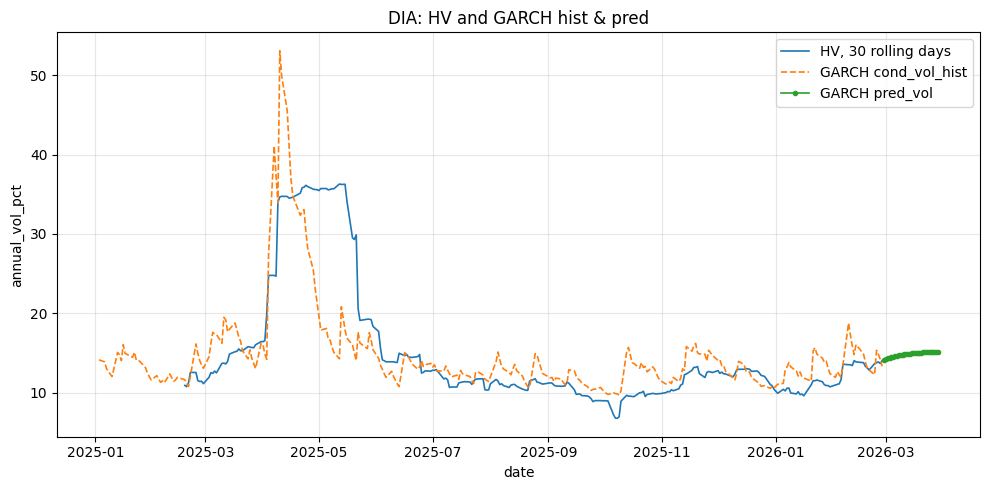

标的 KO 波动率对比（HV / IV / GARCH）


/home/lhsok/miniconda3/envs/trading/lib/python3.10/site-packages/arch/univariate/base.py:2056: FutureWarning: Dtype inference on a pandas object (Series, Index, ExtensionArray) is deprecated. The Index constructor will keep the original dtype in the future. Call `infer_objects` on the result to get the old behavior.
  self._index = pd.Index(index)


,HV annual %,IV annual %,GARCH T+1 annual %,GARCH T+30 annual %,price,expected move,expected range
KO,16.13,22.1,15.67,15.54,81.56,3.55,78.01 ~ 85.11


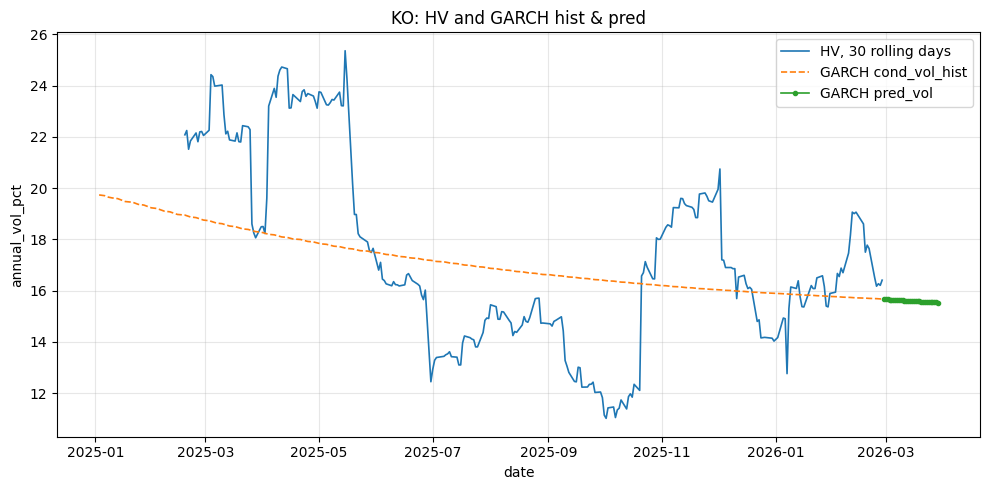

标的 9992.hk 波动率对比（HV / IV / GARCH）


,HV annual %,IV annual %,GARCH T+1 annual %,GARCH T+30 annual %,price,expected move,expected range
9992.hk,58.61,65.28,59.27,60.57,229.8,39.01,190.79 ~ 268.81


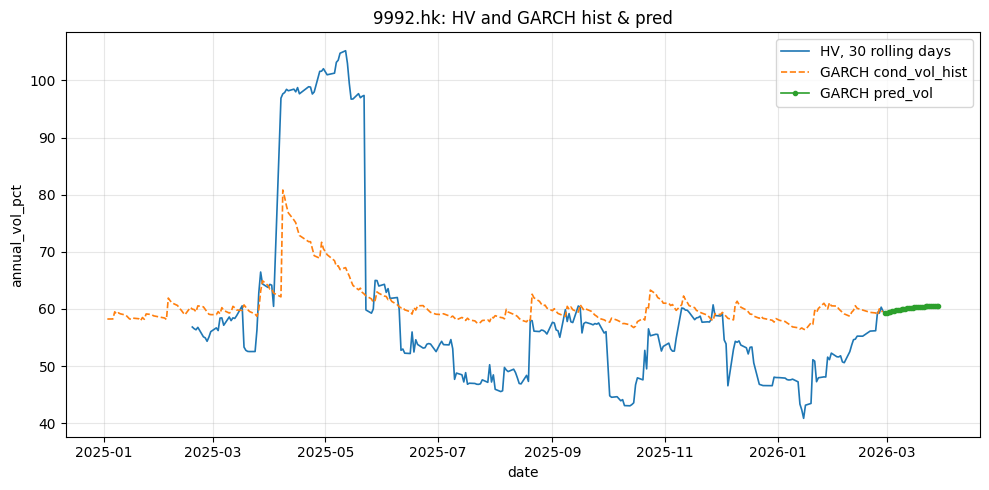

标的 1398.hk 波动率对比（HV / IV / GARCH）


,HV annual %,IV annual %,GARCH T+1 annual %,GARCH T+30 annual %,price,expected move,expected range
1398.hk,19.91,24.38,20.17,20.17,6.45,0.36,6.09 ~ 6.81


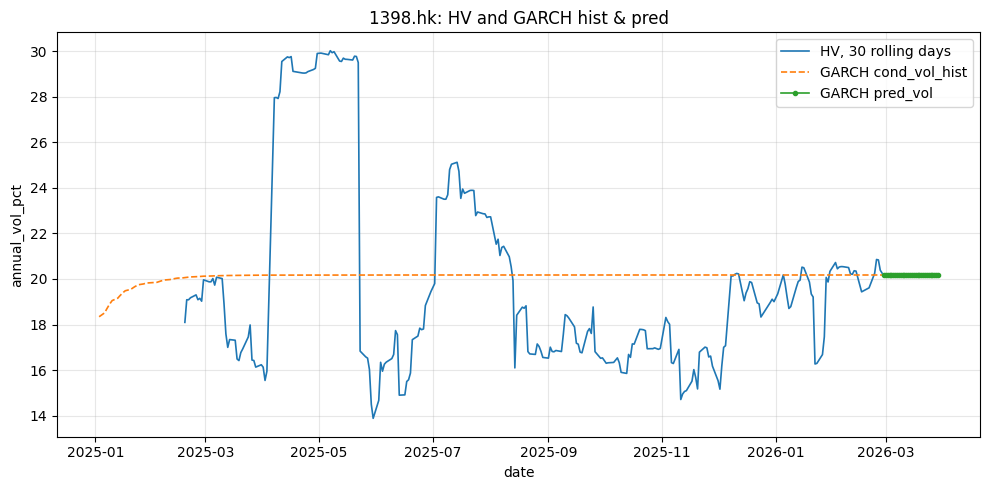

2026-03-01 16:40:57,202 | 11753 | 123244391679680 | [open_context_base.py:516] on_disconnect: Disconnected: conn=0(2) reason=CallClose


In [10]:
import time
start_date = "2025-01-01"
horizon_days = 30

# 复用单一连接 + 每次 IV 后显式 unsubscribe（富途要求订阅满 1 分钟才能取消）
from futu import OpenQuoteContext
quote_ctx = OpenQuoteContext(host=FUTU_HOST, port=FUTU_PORT)
try:
    for sym in ["AAPL", "MSFT", "SPY", "QQQ", "DIA", "KO", "9992.hk", "1398.hk"]:
        result = get_volatility_metrics(sym, start_date, end_date=None, garch_horizon_days=horizon_days, iv_horizon_days=IV_HORIZON_DAYS, hold_period=0.66, quote_ctx=quote_ctx)
        print(f"标的 {sym} 波动率对比（HV / IV / GARCH）")
        display(result["vol_table"])
        plot_hv_garch(result, sym)
finally:
    quote_ctx.close()